In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/Technical Content/data/nigeria.csv')
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40


In [3]:
df["Country"] = "Nigeria"
df["date"] = pd.to_datetime(
df["YEAR"]*1000 + df["DOY"],
format="%Y%j"
)
df["Month"] = df["date"].dt.month

In [4]:
df.head()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,date,Month
0,2015,1,25.23,29.25,22.06,7.19,0.0,68.26,1.73,2.61,100.86,13.36,Nigeria,2015-01-01,1
1,2015,2,26.16,29.41,22.87,6.54,0.0,73.23,1.42,1.95,100.94,15.37,Nigeria,2015-01-02,1
2,2015,3,25.66,29.02,22.63,6.39,0.0,78.71,1.69,2.33,101.06,15.98,Nigeria,2015-01-03,1
3,2015,4,24.11,27.27,19.92,7.35,0.0,63.66,2.15,3.80,101.09,11.65,Nigeria,2015-01-04,1
4,2015,5,23.40,27.28,18.18,9.10,0.0,59.45,1.88,3.48,101.03,10.40,Nigeria,2015-01-05,1


In [5]:
df.to_csv("/content/drive/MyDrive/nigeria_clean.csv", index=False)

In [6]:
print("Missing values:")
print(df.isna().sum().sum())
print("Duplicates:")
print(df.duplicated().sum())

Missing values:
0
Duplicates:
0


After replacing the NASA sentinel values (-999) with NaN, no missing values were found in the dataset. Duplicate row checks also returned zero duplicates. This indicates that the Nigeria climate dataset is complete, consistent, and ready for reliable exploratory analysis without requiring major cleaning.

In [7]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,26.656928,28.914667,24.886461,4.028206,4.213914,85.237040,2.217135,2.903335,100.827205,18.558505,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,21.120000,25.260000,15.170000,1.160000,0.000000,54.400000,0.740000,1.290000,100.380000,9.430000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.720000,27.920000,24.100000,3.090000,0.330000,83.930000,1.770000,2.370000,100.710000,17.970000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,26.820000,28.990000,25.100000,3.770000,1.840000,86.350000,2.200000,2.810000,100.820000,18.840000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,27.540000,29.910000,25.860000,4.600000,5.200000,88.500000,2.630000,3.390000,100.950000,19.570000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,29.290000,32.880000,27.790000,11.730000,166.100000,93.790000,4.780000,6.000000,101.350000,21.740000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.123335,1.294345,1.396727,1.399169,7.266742,5.446007,0.587191,0.696885,0.165321,1.646313,NaN,3.477046


Nigeria shows a warm and relatively stable tropical climate, with an average daily temperature of 26.66°C. Unlike Sudan, temperature variation is much lower, as shown by the small standard deviation of 1.12°C. This suggests more consistent climatic conditions throughout the year, with less exposure to extreme heat fluctuations.

In [8]:
(df["T2M_MAX"] > 35).sum()

np.int64(0)

Nigeria recorded zero days where maximum temperature exceeded 35°C during the study period. This indicates that extreme heat events are much less frequent compared to arid countries like Sudan. Climate vulnerability in Nigeria is therefore more strongly linked to rainfall variability and flooding risk rather than extreme heat.

In [9]:
from scipy.stats import zscore
import numpy as np

cols = ['T2M','PRECTOTCORR']
z = np.abs(zscore(df[cols]))
(z > 3).sum()

np.int64(85)

A total of 85 outlier observations were detected using Z-score analysis. These outliers likely represent significant rainfall events or unusual temperature variations rather than data errors. Since extreme precipitation events are important for flood risk analysis, these observations were retained for climate vulnerability assessment.

In [10]:
import matplotlib.pyplot as plt

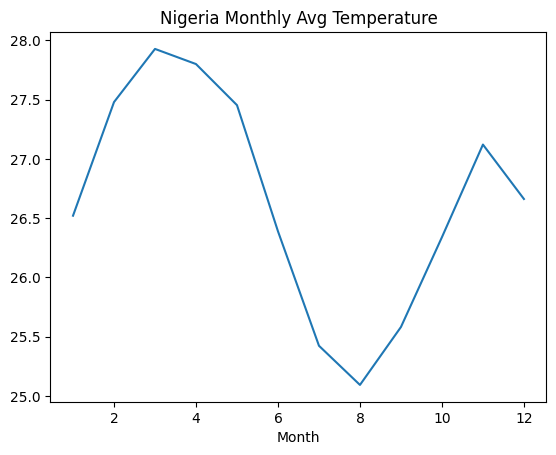

In [11]:
df.groupby('Month')['T2M'].mean().plot()
plt.title("Nigeria Monthly Avg Temperature")
plt.show()

The monthly average temperature plot shows relatively stable temperatures across the year, reflecting Nigeria’s tropical climate pattern. Seasonal variation exists but is much less pronounced than in drier countries. This stability supports agricultural continuity but shifts vulnerability more toward rainfall extremes than heat stress.

March appears to be the warmest month in Nigeria, with temperatures reaching their highest levels before the peak rainy season begins. This reflects the hot dry pre-monsoon period common in tropical climates.

August appears to be the coolest month, likely due to increased cloud cover and rainfall during the rainy season, which lowers average temperatures.

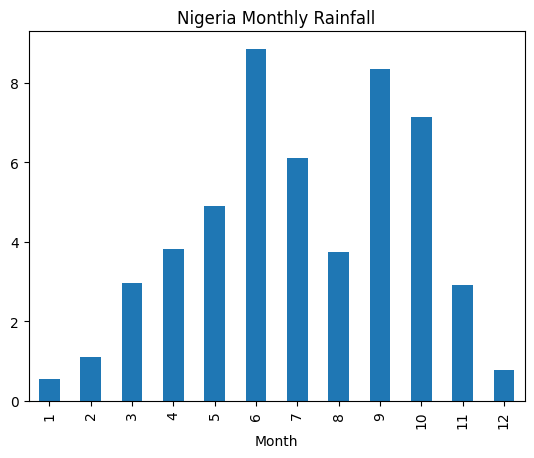

In [18]:
df.groupby('Month')['PRECTOTCORR'].mean().plot(kind='bar')
plt.title("Nigeria Monthly Rainfall")
plt.show()

Rainfall in Nigeria shows strong seasonal concentration, with clear wet and dry periods. Peak rainfall occurs during the rainy season, while dry months show significantly lower precipitation. This seasonal dependence increases vulnerability to both flooding during intense rainy periods and agricultural disruption if rainfall timing changes.

September is likely the peak rainy month, showing the highest average precipitation. This indicates strong seasonal rainfall concentration and highlights flood vulnerability during late rainy season months.

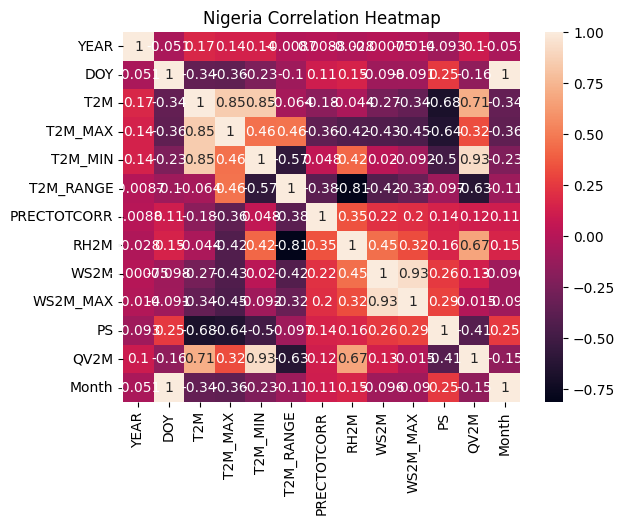

In [13]:
import seaborn as sns
numeric_df = df.select_dtypes(include=["number"])
sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Nigeria Correlation Heatmap")
plt.show()

The heatmap shows strong positive correlations between mean temperature, maximum temperature, and minimum temperature, which is expected in climate observations. Relative humidity tends to show a negative relationship with temperature during hotter periods. Precipitation is positively associated with humidity, reflecting wetter atmospheric conditions during rainfall seasons.

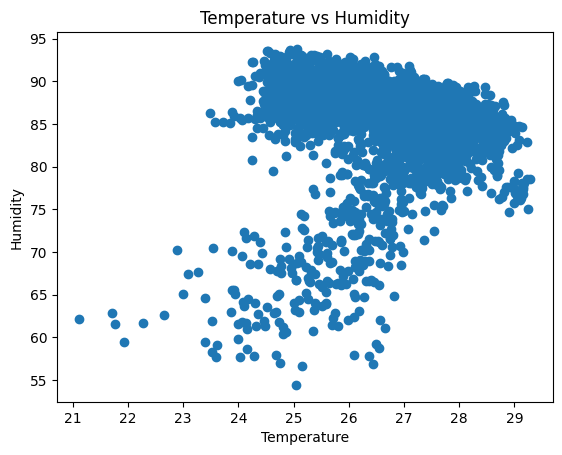

In [14]:
plt.scatter(df["T2M"], df["RH2M"])
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Temperature vs Humidity")
plt.show()

The scatter plot suggests that higher humidity often occurs during periods of moderate temperature rather than peak heat. This reflects Nigeria’s tropical climate where moisture availability is strongly linked to rainfall seasons rather than extreme dry heat.

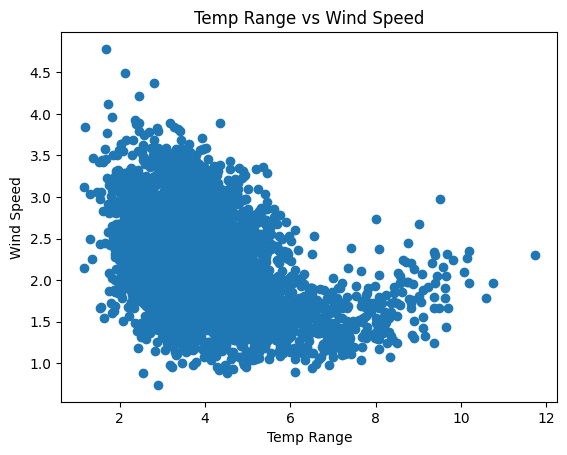

In [15]:
plt.scatter(df["T2M_RANGE"], df["WS2M"])
plt.xlabel("Temp Range")
plt.ylabel("Wind Speed")
plt.title("Temp Range vs Wind Speed")
plt.show()

The relationship between temperature range and wind speed appears relatively weak, suggesting that wind speed is not a major driver of daily temperature variation. Seasonal atmospheric circulation may still influence both variables indirectly.

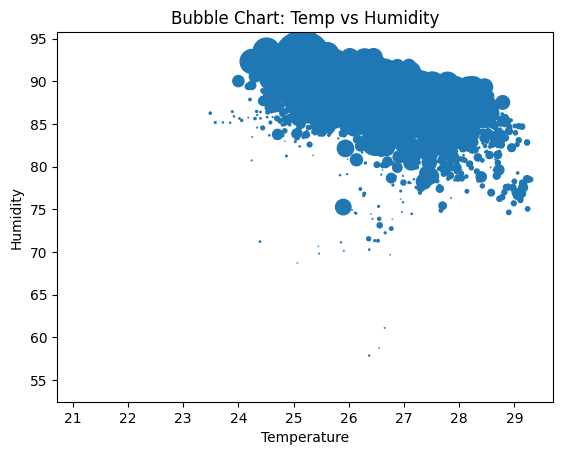

In [16]:
plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"]*10
)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.title("Bubble Chart: Temp vs Humidity")
plt.show()

arger precipitation events are mostly concentrated in areas of higher humidity and moderate temperatures. This confirms that rainfall is closely tied to atmospheric moisture levels and seasonal wet conditions, making precipitation the dominant climate vulnerability factor for Nigeria.